In [1]:
%load_ext autoreload
%autoreload 2

import numpy as np
import matplotlib.pyplot as plt
from scipy import signal
from scipy.optimize import curve_fit, least_squares
import skrf as rf

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal
from scipy.optimize import curve_fit
from scipy.optimize import least_squares

# Inputs for each dataset
VoltMax = 200
VoltStep = 2
DispIndex = 100  # Frequency index for capacitance graph
BVI = 101  # Bias voltage index for single voltage graph
FM = 26.5  # Max frequency to graph
FT = 32  # Graph Font Size
LW = 1  # Line Width
QFSL = 10  # Q factor plot min
QFSH = 10e3  # Q factor plot max
Cap3DL = 0.05  # 3D Capacitance plot min 
Cap3DH = 0.1  # 3D Capacitance plot max
TunL = 1  # Tunability plot min
TunH = 2  # Tunability plot max
LTmin = 0.01  # Loss Tangent min
LTmax = 0.5  # Loss Tangent max

# Commented out parameters
# Y11rL = None  # Y11 Real plot min
# Y11rH = None  # Y11 Real plot max
# Y111L = None  # Y11 Imaginary plot min
# Y111H = None  # Y11 Imaginary plot max
# Y12rL = None  # Y12 Real plot min
# Y12rH = None  # Y12 Real plot max
# Y12iL = None  # Y12 Imaginary plot min
# Y12iH = None  # Y12 Imaginary plot max
# DifY11rL = None  # Difference in the Y11 conductance plot min 
# DifY11rH = None  # Difference in the Y11 conductance plot max

S11min = -5  # S11 Plot min
S11max = 0  # S11 Plot max
S21min = -30  # S21 Plot min
S21max = 0  # S21 Plot max
IDC_gap = 3e-4  # IDC gap size in mm
CF = 0  # Capacitance correction factor

# Variable Definitions
VoltMid = int(VoltMax / VoltStep)
V = np.arange(-VoltMax, VoltMax + VoltStep, VoltStep)
N = len(V)
S = [None] * N
Y = [None] * N
Z = [None] * N
Eff = (V / IDC_gap) / 1000

# Note: In Python, we use lists instead of cell arrays
# The initialization of S, Y, and Z might need to be adjusted 
# depending on what type of data they will hold

print("Setup complete")

Setup complete


In [1]:
import skrf as rf
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal
from scipy.optimize import curve_fit
from scipy.optimize import least_squares

# Importing S2P Files
S = [None] * N
Y = [None] * N
Z = [None] * N

for k in range(VoltMid, N):
    File = f'../datasets/LYW034BTONSO25nm-0D16F200V2S-J/S2P/LYW034BTONSO25nm_0D16F200V2S_J_{V[k]}V_dev.s2p'
    S[k] = rf.Network(File)
    Y[k] = S[k].y
    Z[k] = S[k].z

for k in range(VoltMid):
    File = f'../datasets/LYW034BTONSO25nm-0D16F200V2S-J/S2P/LYW034BTONSO25nm_0D16F200V2S_J_N{V[N-1-k]}V_dev.s2p'
    S[k] = rf.Network(File)
    Y[k] = S[k].y
    Z[k] = S[k].z

# Variable Definitions
Freq = S[0].f
FreqS = Freq / 1e9
w = 2 * np.pi * Freq

# Creating S,Y,Z Variables
S11i = np.zeros((len(Freq), N))
S12i = np.zeros((len(Freq), N))
S21i = np.zeros((len(Freq), N))
S22i = np.zeros((len(Freq), N))
S11r = np.zeros((len(Freq), N))
S12r = np.zeros((len(Freq), N))
S21r = np.zeros((len(Freq), N))
S22r = np.zeros((len(Freq), N))

Y11i = np.zeros((len(Freq), N))
Y12i = np.zeros((len(Freq), N))
Y21i = np.zeros((len(Freq), N))
Y22i = np.zeros((len(Freq), N))
Y11r = np.zeros((len(Freq), N))
Y12r = np.zeros((len(Freq), N))
Y21r = np.zeros((len(Freq), N))
Y22r = np.zeros((len(Freq), N))

Z11i = np.zeros((len(Freq), N))
Z12i = np.zeros((len(Freq), N))
Z21i = np.zeros((len(Freq), N))
Z22i = np.zeros((len(Freq), N))
Z11r = np.zeros((len(Freq), N))
Z12r = np.zeros((len(Freq), N))
Z21r = np.zeros((len(Freq), N))
Z22r = np.zeros((len(Freq), N))

for k in range(N):
    S11i[:, k] = S[k].s[:, 0, 0].imag
    S12i[:, k] = S[k].s[:, 0, 1].imag
    S21i[:, k] = S[k].s[:, 1, 0].imag
    S22i[:, k] = S[k].s[:, 1, 1].imag
    S11r[:, k] = S[k].s[:, 0, 0].real
    S12r[:, k] = S[k].s[:, 0, 1].real
    S21r[:, k] = S[k].s[:, 1, 0].real
    S22r[:, k] = S[k].s[:, 1, 1].real
    
    Y11i[:, k] = Y[k][:, 0, 0].imag
    Y12i[:, k] = Y[k][:, 0, 1].imag
    Y21i[:, k] = Y[k][:, 1, 0].imag
    Y22i[:, k] = Y[k][:, 1, 1].imag
    Y11r[:, k] = Y[k][:, 0, 0].real
    Y12r[:, k] = Y[k][:, 0, 1].real
    Y21r[:, k] = Y[k][:, 1, 0].real
    Y22r[:, k] = Y[k][:, 1, 1].real
    
    Z11i[:, k] = Z[k][:, 0, 0].imag
    Z12i[:, k] = Z[k][:, 0, 1].imag
    Z21i[:, k] = Z[k][:, 1, 0].imag
    Z22i[:, k] = Z[k][:, 1, 1].imag
    Z11r[:, k] = Z[k][:, 0, 0].real
    Z12r[:, k] = Z[k][:, 0, 1].real
    Z21r[:, k] = Z[k][:, 1, 0].real
    Z22r[:, k] = Z[k][:, 1, 1].real

S11m = 20 * np.log10(np.sqrt(S11r**2 + S11i**2))
S12m = 20 * np.log10(np.sqrt(S12r**2 + S12i**2))
S21m = 20 * np.log10(np.sqrt(S21r**2 + S21i**2))
S22m = 20 * np.log10(np.sqrt(S22r**2 + S22i**2))

NameError: name 'N' is not defined

In [ ]:
# Initialize the class with your data
analysis = CapacitorAnalysis(Y12i, Y12r, Y11i, Y11r, w, V, CF, VoltMid, VoltStep, FreqS, DispIndex)

# Run the analysis
analysis.run_analysis()

# Access results
print(analysis.Tunability2D)
print(analysis.QFFiltVolt)

In [7]:
S11m.shape

(2651, 201)

In [4]:
# Capacitance Calculations
Capacitance3D = np.abs((Y12i / w[:, np.newaxis]) / 1e-12)
Capacitance3D -= CF

CapacitanceMin = np.min(Capacitance3D, axis=1)
Capacitance0Volt = Capacitance3D[:, VoltMid]

# Conductance Calculations
Y12Conductance3D = np.abs((Y12r / w[:, np.newaxis]) / 1e-12)
Y11Conductance3D = np.abs((Y11r / w[:, np.newaxis]) / 1e-12)

DiffConductance3D = Y12Conductance3D + Y11Conductance3D

# Tunability Calculations
Tunability3D = Capacitance3D[:, VoltMid][:, np.newaxis] / Capacitance3D
Tunability2D = Capacitance0Volt / CapacitanceMin

# Quality Factor Calculations
QualityFactor = np.abs(Y12i / Y12r)

# Loss Tangent Calculations
LossTan = np.abs(Y11r / Y11i)

# Commutation Quality Factor Calculations
ZZ12i = 1 / Y12i
ZZ12r = 1 / Y12r

CQF = (np.abs((Y12i[:, VoltMid] - Y12i[:, -1])**2 / (Y12r[:, VoltMid] * Y12r[:, -1])) +
       np.abs((Y12i[:, VoltMid] - Y12i[:, 0])**2 / (Y12r[:, VoltMid] * Y12r[:, 0]))) / 2

# Peak Q Factor at Each Frequency
QualityFactorT = QualityFactor.T
QFS = QualityFactorT.shape
QFMF = np.zeros((VoltMid, QFS[1]))

for Index in range(VoltMid):
    QFMF[Index, :] = QualityFactorT[Index + VoltMid, :]

Vh = V[VoltMid:QFS[0]]
VoltQPeak = np.zeros(len(FreqS))
VoltQPeakCor = np.zeros(len(FreqS))
j, k = np.max(QFMF, axis=0), np.argmax(QFMF, axis=0)

VoltQPeak = k

B, A = signal.butter(2, 0.1, 'low')
QFFilt = signal.filtfilt(B, A, VoltQPeak)
QFFiltVolt = (QFFilt * VoltStep) - VoltStep

# Capacitance Fitting
def fitting_function(p, V):
    return (p[0] - p[2]) / (2 * np.cosh(2/3 * np.arcsinh(2 * V / p[1])) - 1) + p[2]

voltages = V
popts = []

for n in range(len(FreqS)):
    Capacitance_at_DispIndex = Capacitance3D[DispIndex, :]
    initial_guess = [4.5e-13, 45, 1e-13]
    
    # Corrected line:
    result = least_squares(lambda p: fitting_function(p, voltages) - Capacitance_at_DispIndex, initial_guess)
    popt = result.x  # Extract the optimized parameters
    
    Cmax_fitted, V_half_fitted, Cf_fitted = popt
    V_fit = np.linspace(min(voltages), max(voltages), 1000)
    C_fit = fitting_function(popt, V_fit)
    popts.append(popt)

# Save Variable
np.save('LYW034BTONSO25nm_0D16F200V2S_J_Tunability.npy', Tunability2D)
np.save('LYW034BTONSO25nm_0D16F200V2S_J_QFPeakatFreq.npy', QFFiltVolt)

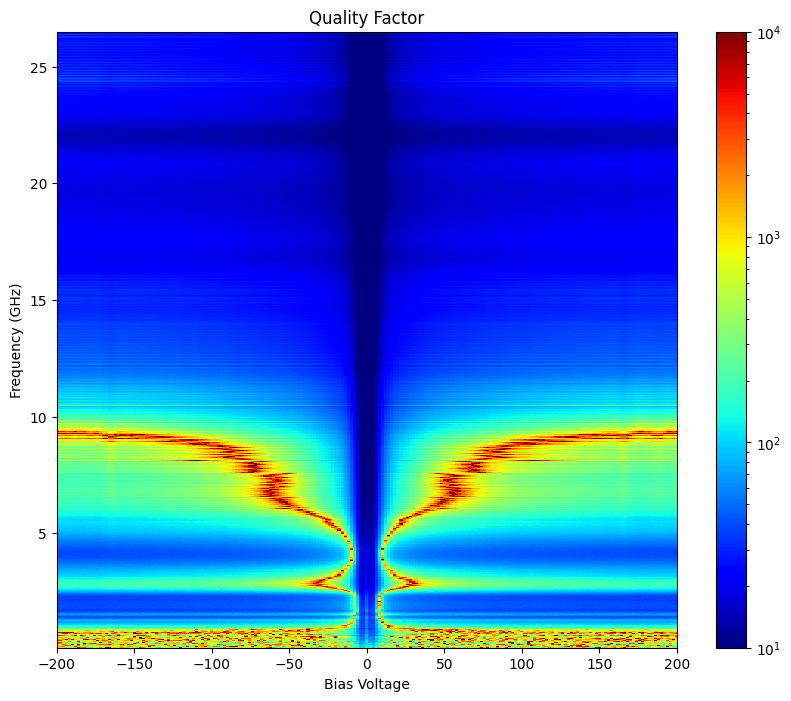

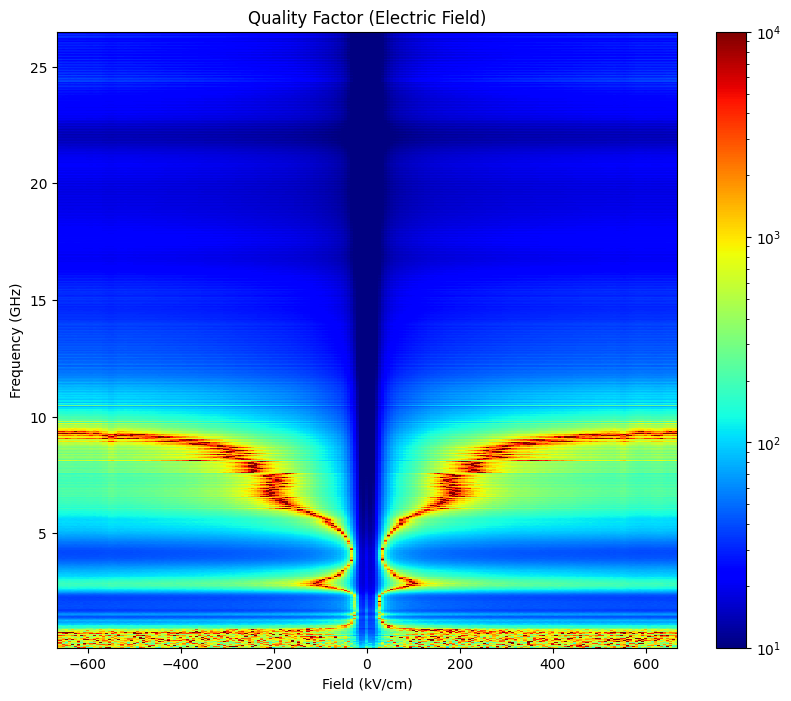

In [28]:
from matplotlib.colors import LogNorm

# Figure Generation
plt.figure(figsize=(5, 4))
plt.title('Quality Factor')
plt.pcolormesh(V, FreqS, QualityFactor, shading='auto', cmap='jet', norm=LogNorm(vmin=QFSL, vmax=QFSH))
plt.colorbar()
plt.xlim(-VoltMax, VoltMax)
plt.ylim(0.1, FM)
plt.xlabel('Bias Voltage')
plt.ylabel('Frequency (GHz)')
plt.show()

plt.figure(figsize=(5, 4))
plt.title('Quality Factor (Electric Field)')
plt.pcolormesh((V/IDC_gap)/1000, FreqS, QualityFactor, shading='auto', cmap='jet', norm=LogNorm(vmin=QFSL, vmax=QFSH))
plt.colorbar()
plt.xlim(-(VoltMax/IDC_gap)/1000, (VoltMax/IDC_gap)/1000)
plt.ylim(0.1, FM)
plt.xlabel('Field (kV/cm)')
plt.ylabel('Frequency (GHz)')
plt.show()

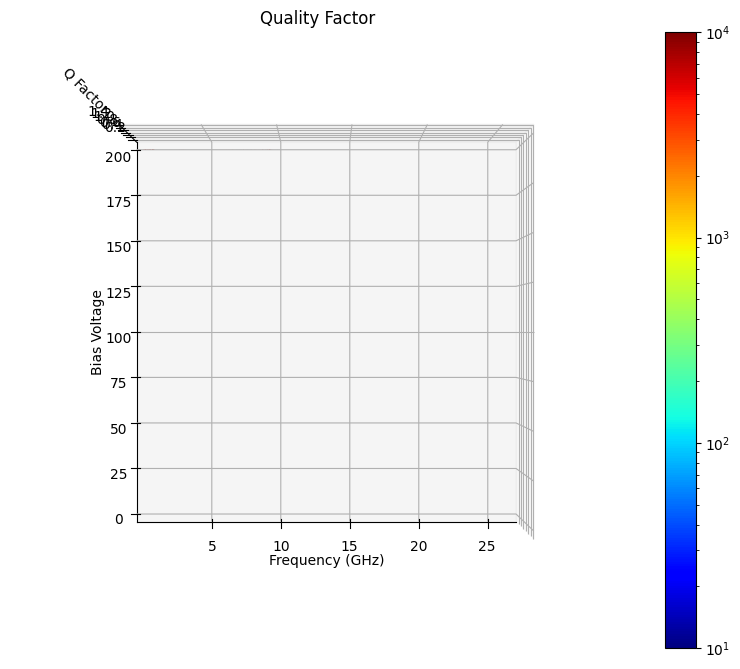

/var/folders/vw/f9yhqktd2dn424wq_qcx58vsgjs7t2/T/ipykernel_70580/3612029310.py:27: UserWarning: Attempt to set non-positive ylim on a log-scaled axis will be ignored.
  plt.ylim(0, np.max(QualityFactor))


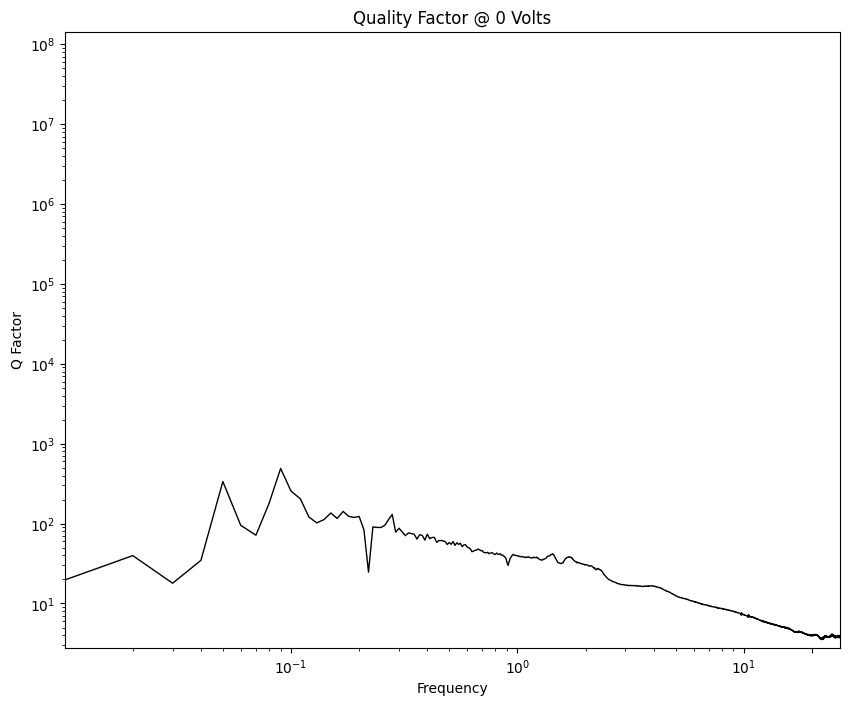

/var/folders/vw/f9yhqktd2dn424wq_qcx58vsgjs7t2/T/ipykernel_70580/3612029310.py:45: UserWarning: Attempt to set non-positive ylim on a log-scaled axis will be ignored.
  plt.ylim(0, np.max(QualityFactor))


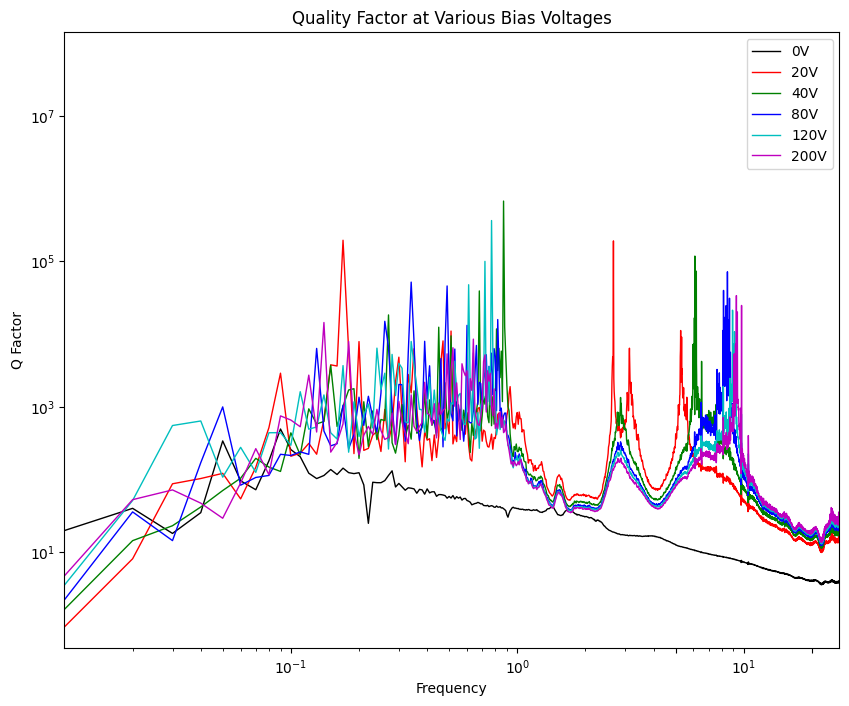

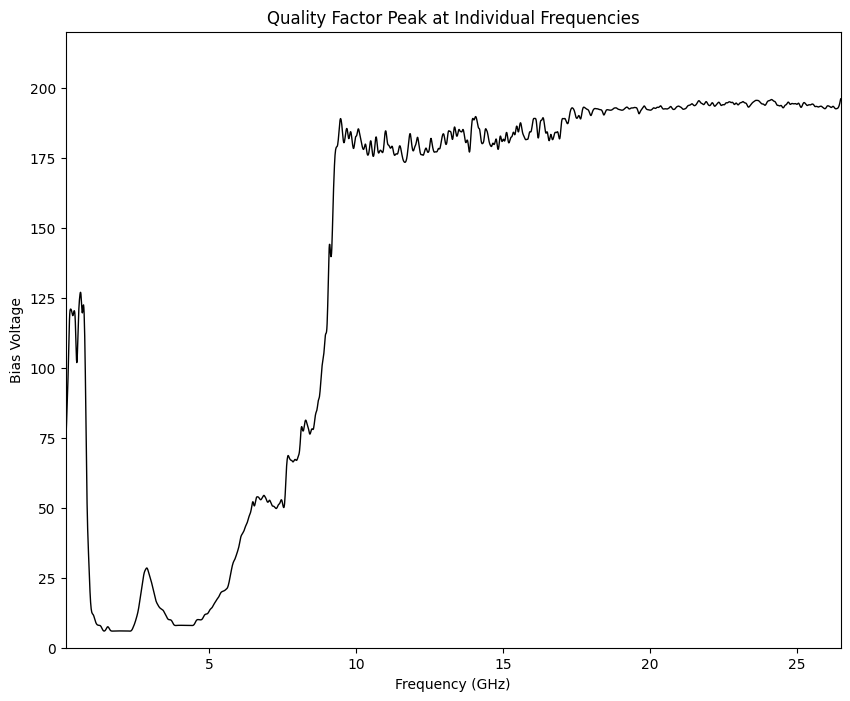

In [37]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import numpy as np

FreqS_2D, Vh_2D = np.meshgrid(FreqS, Vh)

# Quality Factor Positive Voltage Bias
fig = plt.figure(figsize=(5, 4))
ax = fig.add_subplot(111, projection='3d')
surf = ax.plot_surface(FreqS_2D[-1:], Vh[-1:], QFMF, cmap='jet', norm=LogNorm(vmin=QFSL, vmax=QFSH))
ax.set_xlim(0.1, FM)
ax.set_ylim(0, VoltMax)
ax.view_init(90, 270)
ax.set_xlabel('Frequency (GHz)')
ax.set_ylabel('Bias Voltage')
ax.set_zlabel('Q Factor')
ax.set_title('Quality Factor')
fig.colorbar(surf)
plt.show()

# Quality Factor at Specific Bias Voltage
plt.figure(figsize=(5, 4))
plt.plot(FreqS, QualityFactor[:, BVI], 'k', linewidth=LW)
plt.xscale('log')
plt.yscale('log')
plt.xlim(min(FreqS), FM)
plt.ylim(0, np.max(QualityFactor))
plt.xticks([0.1, 1, 10, 20])
plt.xlabel('Frequency')
plt.ylabel('Q Factor')
plt.title('Quality Factor @ 0 Volts')
plt.show()

# Quality Factor at Various Bias Voltages
plt.figure(figsize=(5, 4))
plt.plot(FreqS, QualityFactor[:, BVI], 'k', linewidth=LW, label='0V')
plt.plot(FreqS, QualityFactor[:, 110], 'r', linewidth=LW, label='20V')
plt.plot(FreqS, QualityFactor[:, 120], 'g', linewidth=LW, label='40V')
plt.plot(FreqS, QualityFactor[:, 140], 'b', linewidth=LW, label='80V')
plt.plot(FreqS, QualityFactor[:, 160], 'c', linewidth=LW, label='120V')
plt.plot(FreqS, QualityFactor[:, 200], 'm', linewidth=LW, label='200V')
plt.xscale('log')
plt.yscale('log')
plt.xlim(min(FreqS), FM)
plt.ylim(0, np.max(QualityFactor))
plt.xticks([0.1, 1, 5, 10, 20])
plt.xlabel('Frequency')
plt.ylabel('Q Factor')
plt.title('Quality Factor at Various Bias Voltages')
plt.legend()
plt.show()

# Q Peak Location
plt.figure(figsize=(5, 4))
plt.plot(FreqS, QFFiltVolt, 'k', linewidth=LW)
plt.xlim(0.1, FM)
plt.ylim(0, VoltMax*1.1)
plt.xlabel('Frequency (GHz)')
plt.ylabel('Bias Voltage')
plt.title('Quality Factor Peak at Individual Frequencies')
plt.show()


In [7]:
Capacitance3D.shape

(2651, 201)

In [ ]:

# 3D Capacitance
fig = plt.figure(figsize=(5, 4))
ax = fig.add_subplot(111, projection='3d')
surf = ax.plot_surface(V, FreqS, Capacitance3D, cmap='jet')
ax.set_xlim(-VoltMax, VoltMax)
ax.set_ylim(0.1, FM)
ax.view_init(45, 45)
ax.set_xlabel('Bias Voltage')
ax.set_ylabel('Frequency (GHz)')
ax.set_zlabel('Capacitance (pF)')
ax.set_title('Capacitance')
fig.colorbar(surf)
plt.show()

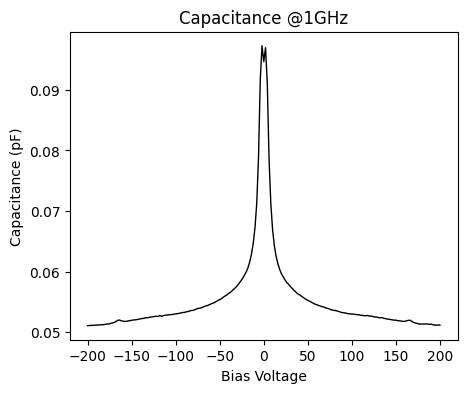

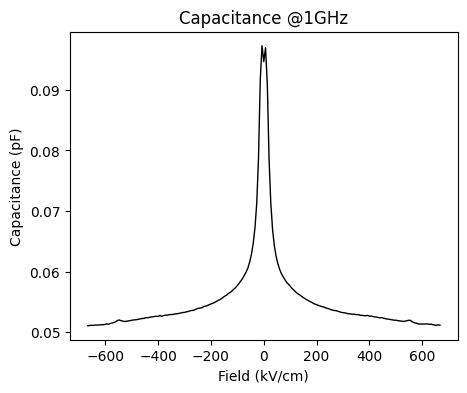

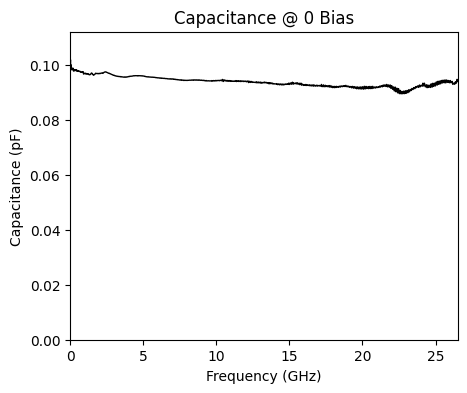

ValueError: 'south' is not a valid value for loc; supported values are 'best', 'upper right', 'upper left', 'lower left', 'lower right', 'right', 'center left', 'center right', 'lower center', 'upper center', 'center'

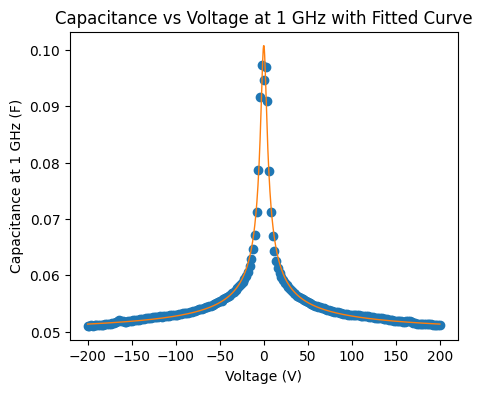

In [5]:

# 3D Capacitance
fig = plt.figure(figsize=(5, 4))
ax = fig.add_subplot(111, projection='3d')
surf = ax.plot_surface(V, FreqS, Capacitance3D, cmap='jet')
ax.set_xlim(-VoltMax, VoltMax)
ax.set_ylim(0.1, FM)
ax.set_zlim(Cap3DL, Cap3DH)
ax.view_init(45, 45)
ax.set_xlabel('Bias Voltage')
ax.set_ylabel('Frequency (GHz)')
ax.set_zlabel('Capacitance (pF)')
ax.set_title('Capacitance')
fig.colorbar(surf)
plt.show()

# 2D Capacitance at Specific Frequency (Bias Voltage)
plt.figure(figsize=(5, 4))
plt.plot(V, Capacitance3D[DispIndex, :], 'k', linewidth=LW)
plt.xlabel('Bias Voltage')
plt.ylabel('Capacitance (pF)')
plt.title('Capacitance @1GHz')
plt.show()

# 2D Capacitance at Specific Frequency (Electric Field)
plt.figure(figsize=(5, 4))
plt.plot((V/IDC_gap)/1000, Capacitance3D[DispIndex, :], 'k', linewidth=LW)
plt.xlabel('Field (kV/cm)')
plt.ylabel('Capacitance (pF)')
plt.title('Capacitance @1GHz')
plt.show()

# 2D Capacitance at Specific Bias Voltage
plt.figure(figsize=(5, 4))
plt.plot(FreqS, Capacitance3D[:, BVI], 'k', linewidth=LW)
plt.xlim(0, max(FreqS))
plt.ylim(0, max(Capacitance3D[:, BVI])*1.1)
plt.xlabel('Frequency (GHz)')
plt.ylabel('Capacitance (pF)')
plt.title('Capacitance @ 0 Bias')
plt.show()

# Fitted Curve for Capacitance
plt.figure(figsize=(5, 4))
plt.plot(voltages, Capacitance_at_DispIndex, 'o', label='Data', linewidth=LW)
plt.plot(V_fit, C_fit, '-', label=f'Fit: C_max={Cmax_fitted:.2e}, V_1/2={V_half_fitted:.2f}, C_f={Cf_fitted:.2e}', linewidth=LW)
plt.xlabel('Voltage (V)')
plt.ylabel('Capacitance at 1 GHz (F)')
plt.title('Capacitance vs Voltage at 1 GHz with Fitted Curve')
plt.legend(loc='south')
plt.grid(True)
plt.show()

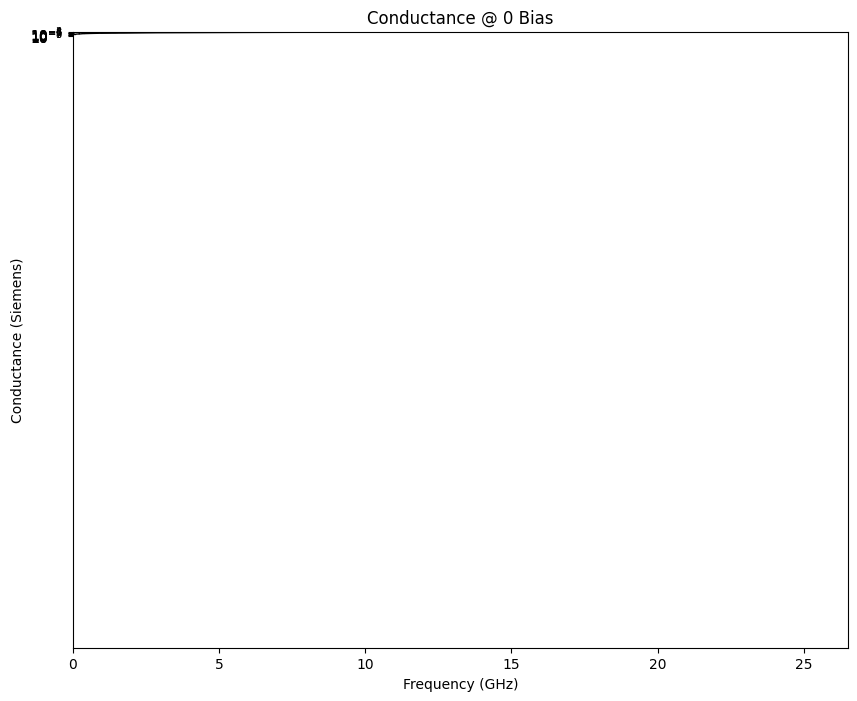

ValueError: not enough values to unpack (expected 3, got 2)

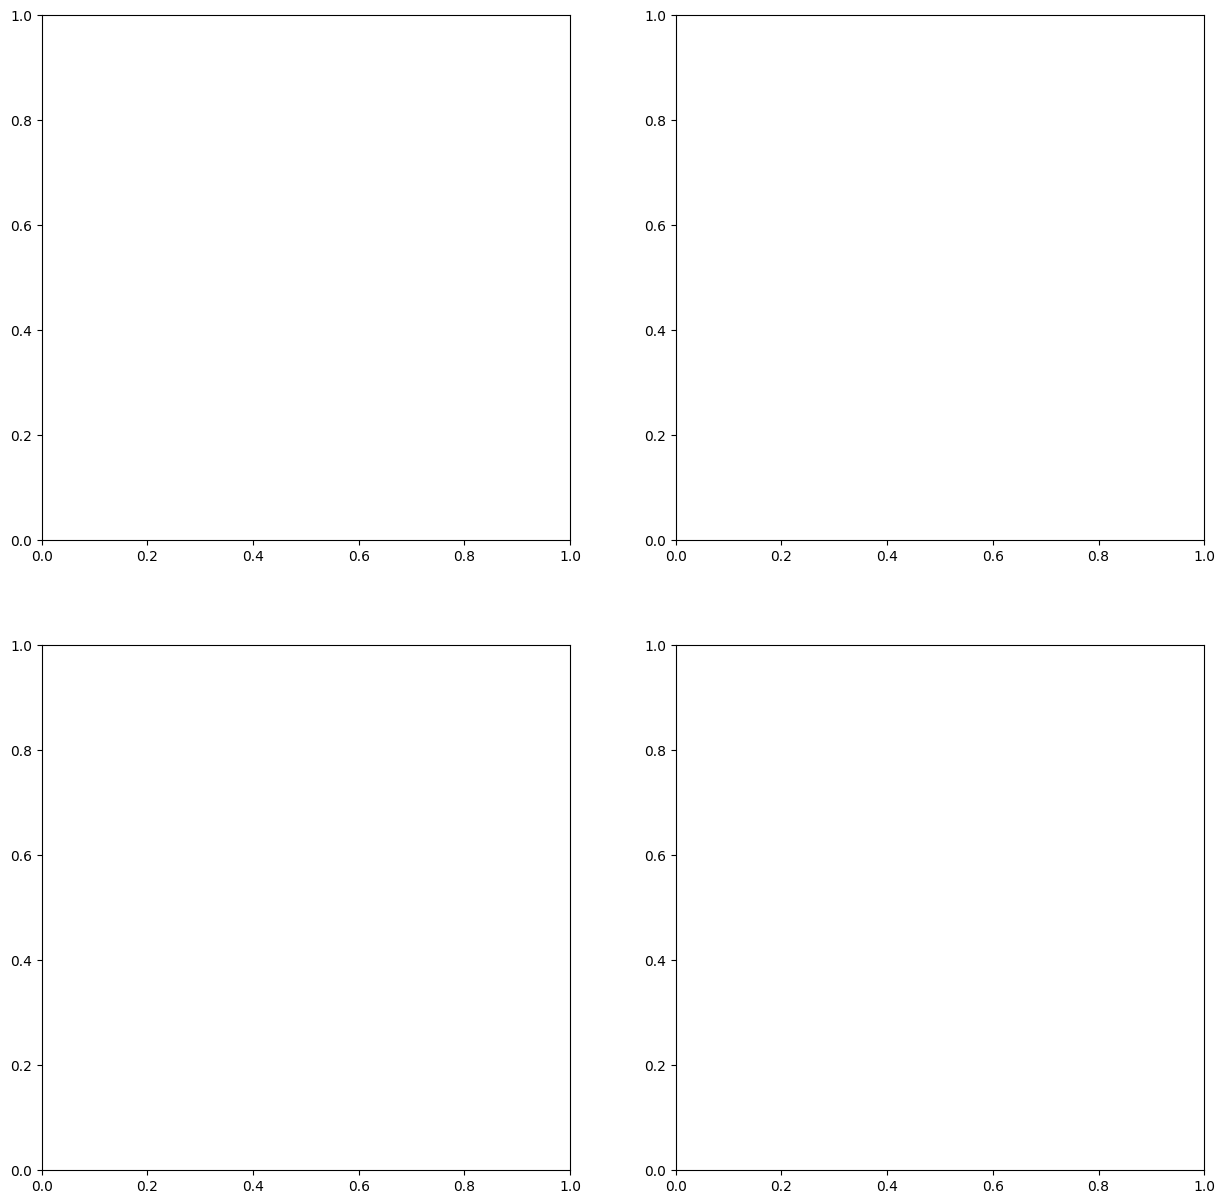

In [42]:

# 2D Conductance at Specific Bias Voltage
plt.figure(figsize=(5, 4))
plt.plot(FreqS, np.abs(Y12r[:, BVI]), 'k', linewidth=LW)
plt.xlim(0, FM)
plt.ylim(0, max(np.abs(Y12r[:, BVI]))*1.1)
plt.yscale('log')
plt.xlabel('Frequency (GHz)')
plt.ylabel('Conductance (Siemens)')
plt.title('Conductance @ 0 Bias')
plt.show()

# Conductance and Capacitance Comparison
fig, (ax1, ax2, ax3) = plt.subplots(2, 2, figsize=(15, 15))
ax1 = plt.subplot2grid((2, 2), (0, 0), colspan=2)
ax1.plot(FreqS, QualityFactor[:, BVI], 'k', linewidth=LW)
ax1.set_yscale('log')
ax1.set_xticks([0.1, 1, 10, 20])
ax1.set_xlabel('Frequency (GHz)')
ax1.set_ylabel('Q Factor')

ax2.plot(FreqS, Capacitance3D[:, BVI], 'k', linewidth=LW)
ax2.set_xlim(0, max(FreqS))
ax2.set_ylim(0, max(Capacitance3D[:, BVI])*1.1)
ax2.set_ylabel('Capacitance (pF)')

ax3.plot(FreqS, np.abs(Y12r[:, BVI]), 'k', linewidth=LW)
ax3.set_xlim(0, max(FreqS))
ax3.set_ylim(0, max(np.abs(Y12r[:, BVI]))*1.1)
ax3.set_yscale('log')
ax3.set_xlabel('Frequency (GHz)')
ax3.set_ylabel('Conductance (Siemens)')

plt.suptitle('Conductance and Capacitance Comparison', fontsize=FT)
plt.show()

ValueError: shape mismatch: objects cannot be broadcast to a single shape.  Mismatch is between arg 0 with shape (201,) and arg 1 with shape (2651,).

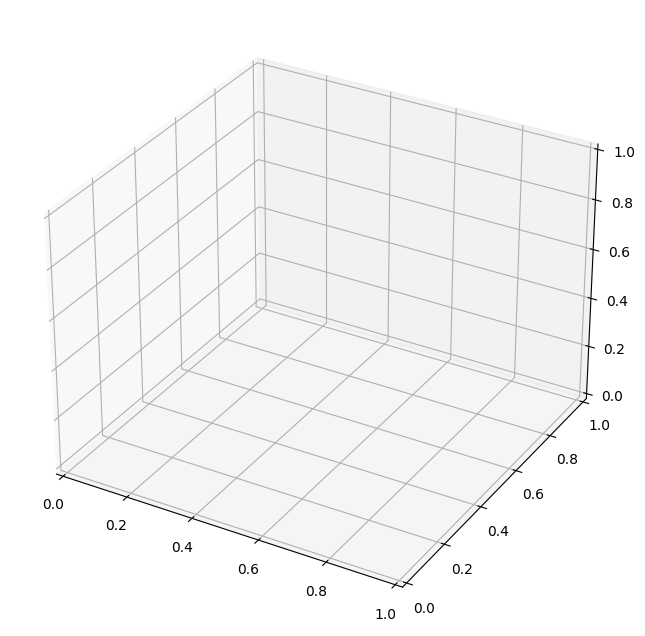

In [43]:

# 3D Tunability
fig = plt.figure(figsize=(5, 4))
ax = fig.add_subplot(111, projection='3d')
surf = ax.plot_surface(V, FreqS, Tunability3D, cmap='jet')
ax.set_xlim(-VoltMax, VoltMax)
ax.set_ylim(0.1, FM)
ax.set_zlim(TunL, TunH)
ax.view_init(45, 45)
ax.set_xlabel('Bias Voltage')
ax.set_ylabel('Frequency (GHz)')
ax.set_zlabel('Tunability')
ax.set_title('Tunability')
fig.colorbar(surf)
plt.show()

# 2D Tunability
plt.figure(figsize=(5, 4))
plt.plot(FreqS, Tunability2D, 'k', linewidth=LW)
plt.xlim(0.1, FM)
plt.ylim(TunL, TunH)
plt.xscale('log')
plt.xticks([0.1, 1, 10, 20])
plt.xlabel('Frequency (GHz)')
plt.ylabel('Tunability')
plt.title('Tunability')
plt.show()


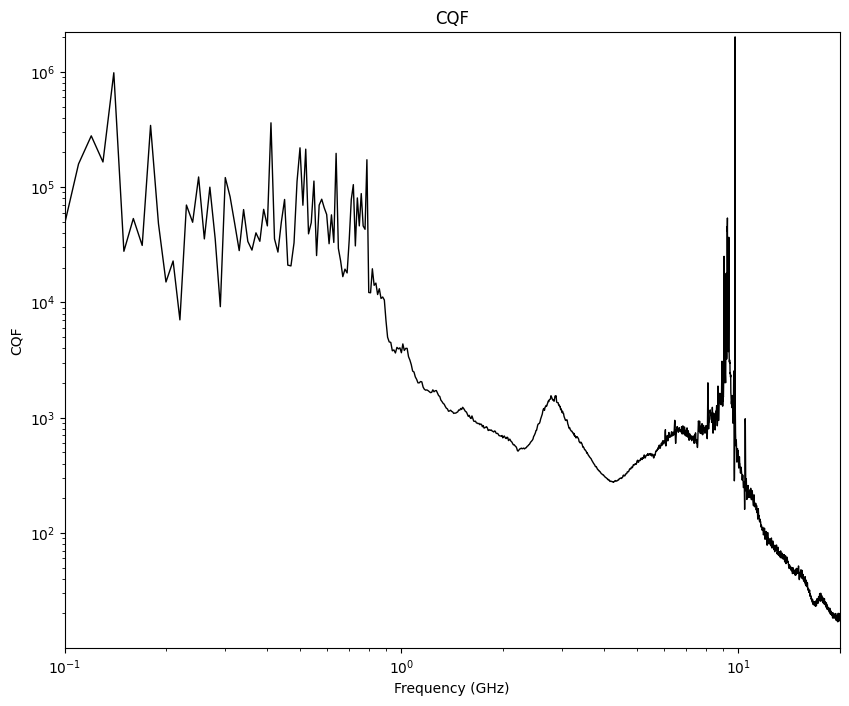

ValueError: shape mismatch: objects cannot be broadcast to a single shape.  Mismatch is between arg 0 with shape (201,) and arg 1 with shape (2651,).

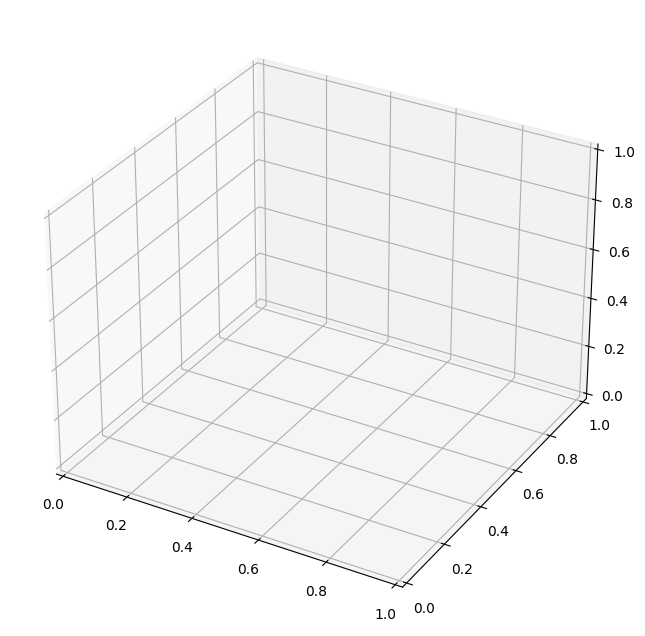

In [44]:

# CQF
plt.figure(figsize=(5, 4))
plt.plot(FreqS, CQF, 'k', linewidth=LW)
plt.xlim(0.1, 20)
plt.ylim(min(CQF)/1.1, max(CQF)*1.1)
plt.xscale('log')
plt.yscale('log')
plt.xticks([0.1, 1, 10, 20])
plt.xlabel('Frequency (GHz)')
plt.ylabel('CQF')
plt.title('CQF')
plt.show()

# Loss Tangent
fig = plt.figure(figsize=(5, 4))
ax = fig.add_subplot(111, projection='3d')
surf = ax.plot_surface(V, FreqS, LossTan, cmap='jet', norm=LogNorm(vmin=LTmin, vmax=LTmax))
ax.set_xlim(-VoltMax, VoltMax)
ax.set_ylim(0.1, FM)
ax.view_init(0, 90)
ax.set_xlabel('Bias Voltage')
ax.set_ylabel('Frequency (GHz)')
ax.set_zlabel('Loss Tangent')
ax.set_title('Loss Tangent')
fig.colorbar(surf)
plt.show()


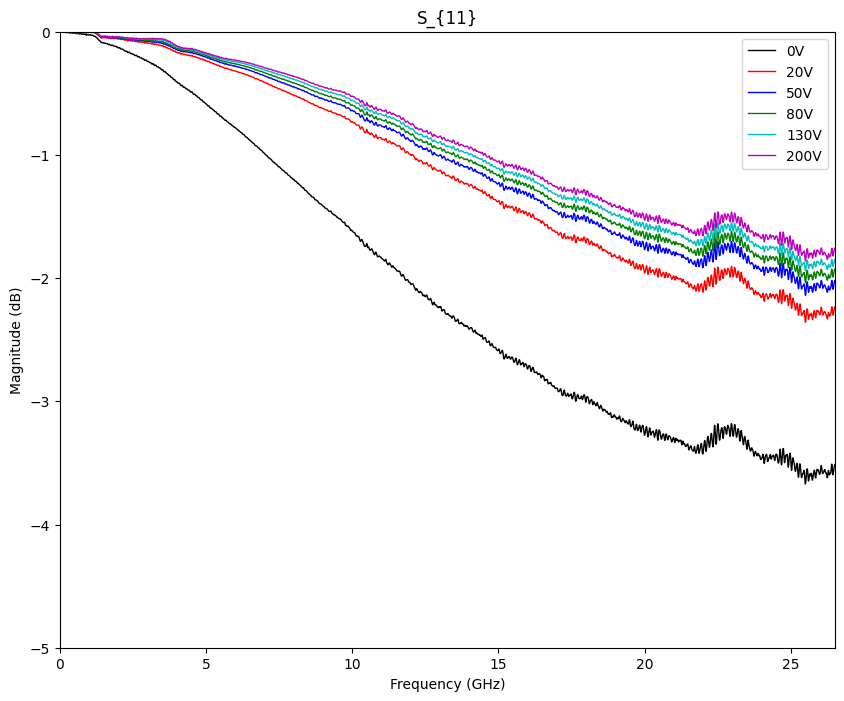

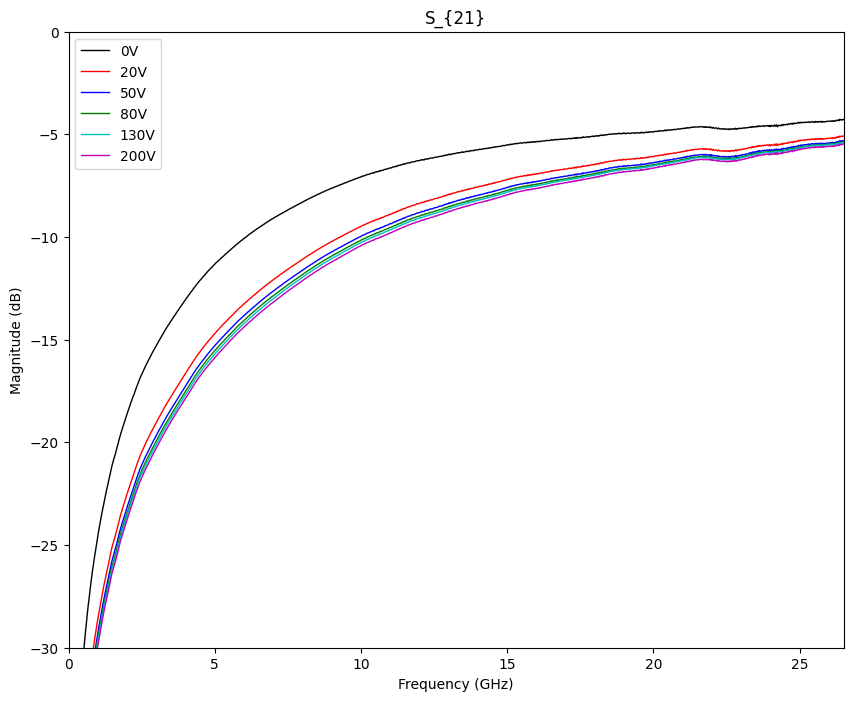

In [45]:

# S Parameters
plt.figure(figsize=(5, 4))
plt.plot(FreqS, S11m[:, 100], 'k', linewidth=LW, label='0V')
plt.plot(FreqS, S11m[:, 110], 'r', linewidth=LW, label='20V')
plt.plot(FreqS, S11m[:, 125], 'b', linewidth=LW, label='50V')
plt.plot(FreqS, S11m[:, 140], 'g', linewidth=LW, label='80V')
plt.plot(FreqS, S11m[:, 165], 'c', linewidth=LW, label='130V')
plt.plot(FreqS, S11m[:, 200], 'm', linewidth=LW, label='200V')
plt.xlim(0, FM)
plt.ylim(S11min, S11max)
plt.xlabel('Frequency (GHz)')
plt.ylabel('Magnitude (dB)')
plt.title('S_{11}')
plt.legend()
plt.show()

plt.figure(figsize=(5, 4))
plt.plot(FreqS, S21m[:, 100], 'k', linewidth=LW, label='0V')
plt.plot(FreqS, S21m[:, 110], 'r', linewidth=LW, label='20V')
plt.plot(FreqS, S21m[:, 125], 'b', linewidth=LW, label='50V')
plt.plot(FreqS, S21m[:, 140], 'g', linewidth=LW, label='80V')
plt.plot(FreqS, S21m[:, 165], 'c', linewidth=LW, label='130V')
plt.plot(FreqS, S21m[:, 200], 'm', linewidth=LW, label='200V')
plt.xlim(0, FM)
plt.ylim(S21min, S21max)
plt.xlabel('Frequency (GHz)')
plt.ylabel('Magnitude (dB)')
plt.title('S_{21}')
plt.legend()
plt.show()


ValueError: shape mismatch: objects cannot be broadcast to a single shape.  Mismatch is between arg 0 with shape (201,) and arg 1 with shape (2651,).

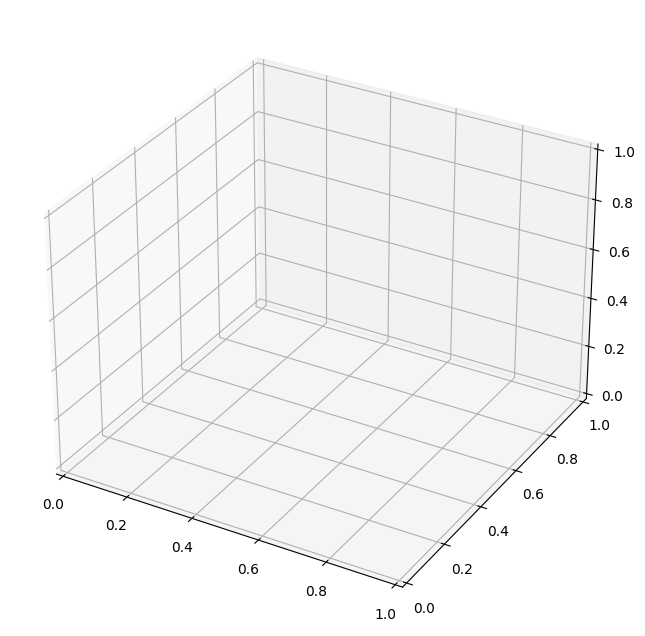

In [46]:

# Note: The rfplot function doesn't have a direct equivalent in Python.
# You might need to implement a custom function to replicate its behavior.

# Y12 Imaginary
fig = plt.figure(figsize=(5, 4))
ax = fig.add_subplot(111, projection='3d')
surf = ax.plot_surface(V, FreqS, np.abs(Y12i), cmap='jet', norm=LogNorm())
ax.set_xlim(-VoltMax, VoltMax)
ax.set_ylim(0.1, FM)
ax.view_init(0, 90)
ax.set_xlabel('Bias Voltage')
ax.set_ylabel('Frequency (GHz)')
ax.set_zlabel('Reactance')
ax.set_title('Reactance')
fig.colorbar(surf)
plt.show()

# Y12 Real
fig = plt.figure(figsize=(5, 4))
ax = fig.add_subplot(111, projection='3d')
surf = ax.plot_surface(V, FreqS, Y12Conductance3D, cmap='jet', norm=LogNorm())
ax.set_xlim(-VoltMax, VoltMax)
ax.set_ylim(0.1, FM)
ax.view_init(0, 90)
ax.set_xlabel('Bias Voltage')
ax.set_ylabel('Frequency (GHz)')
ax.set_zlabel('Conductance (Siemens)')
ax.set_title('Conductance')
fig.colorbar(surf)
plt.show()

# Y11 Imaginary
fig = plt.figure(figsize=(5, 4))
ax = fig.add_subplot(111, projection='3d')
surf = ax.plot_surface(V, FreqS, np.abs(Y11i), cmap='jet', norm=LogNorm())
ax.set_xlim(-VoltMax, VoltMax)
ax.set_ylim(0.1, FM)
ax.view_init(0, 90)
ax.set_xlabel('Bias Voltage')
ax.set_ylabel('Frequency (GHz)')
ax.set_zlabel('Reactance')
ax.set_title('Reactance')
fig.colorbar(surf)
plt.show()

# Y11 Real
fig = plt.figure(figsize=(5, 4))
ax = fig.add_subplot(111, projection='3d')
surf = ax.plot_surface(V, FreqS, Y11Conductance3D, cmap='jet', norm=LogNorm())
ax.set_xlim(-VoltMax, VoltMax)
ax.set_ylim(0.1, FM)
ax.view_init(0, 90)
ax.set_xlabel('Bias Voltage')
ax.set_ylabel('Frequency (GHz)')
ax.set_zlabel('Conductance (Siemens)')
# Y11 Real (continued)
ax.set_title('Conductance')
fig.colorbar(surf)
plt.show()


ValueError: shape mismatch: objects cannot be broadcast to a single shape.  Mismatch is between arg 0 with shape (201,) and arg 1 with shape (2651,).

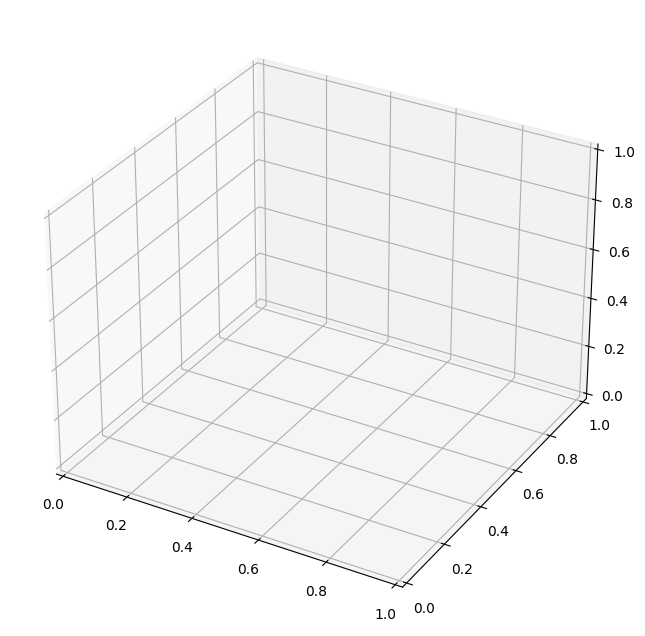

In [47]:

# Difference in Conduction
fig = plt.figure(figsize=(5, 4))
ax = fig.add_subplot(111, projection='3d')
surf = ax.plot_surface(V, FreqS, np.abs(DiffConductance3D), cmap='jet', norm=LogNorm())
ax.set_xlim(-VoltMax, VoltMax)
ax.set_ylim(0.1, FM)
ax.view_init(0, 90)
ax.set_xlabel('Bias Voltage')
ax.set_ylabel('Frequency (GHz)')
ax.set_zlabel('Difference in Conductance')
ax.set_title('Difference in Conductance')
fig.colorbar(surf)
plt.show()

# Note: The following plots (S11 and S21 using rfplot) don't have a direct equivalent in Python
# You might need to implement a custom function to replicate rfplot's behavior
# Here's a placeholder for these plots:

def rfplot(S, i, j):
    # Implement this function to replicate MATLAB's rfplot behavior
    # This is just a placeholder
    return plt.plot(FreqS, np.abs(S[:, i-1, j-1]))

# S11 Plots
plt.figure(figsize=(5, 4))
colors = ['r', 'g', 'b', 'y', 'c', 'm', (0.5, 0, 0), (0, 0.5, 0), (0, 0, 0.5), (0.5, 0.5, 0)]
voltages = [0, 10, 20, 30, 40, 60, 80, 100, 150, 200]
for s, color, voltage in zip([S[100], S[105], S[110], S[115], S[120], S[130], S[140], S[150], S[175], S[200]], colors, voltages):
    h = rfplot(s, 1, 1)
    plt.setp(h, color=color, linewidth=LW)
plt.xlim(0, FM)
plt.ylim(S11min, S11max)
plt.title('S_{11}')
plt.xlabel('Frequency (GHz)')
plt.ylabel('S_{11} (dB)')
plt.legend([f'{v}V' for v in voltages])
plt.show()

# S21 Plots
plt.figure(figsize=(5, 4))
for s, color, voltage in zip([S[100], S[105], S[110], S[115], S[120], S[130], S[140], S[150], S[175], S[200]], colors, voltages):
    h = rfplot(s, 2, 1)
    plt.setp(h, color=color, linewidth=LW)
plt.xlim(0, FM)
plt.ylim(S21min, S21max)
plt.title('S_{21}')
plt.xlabel('Frequency (GHz)')
plt.ylabel('S_{21} (dB)')
plt.legend([f'{v}V' for v in voltages])
plt.show()